In [8]:
##### Correlation between capital and labor intensity, and bivariate classification
# Country-scale + pixel-scale correlation, scatterplots, and 3x3 LMH classification map

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

In [9]:
##### Load data

cd = os.path.dirname(os.getcwd())

capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne.tif")

country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/correlation_capital_labor"

In [10]:
##### Data prep

# align rasters
crs = capital_intensity.rio.crs
labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)
country_boundaries = country_boundaries.to_crs(crs)

# merge country-level data
country_boundaries = country_boundaries.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='left')
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

In [11]:
##### Correlation: country scale

country_valid = country_boundaries[
    country_boundaries['capital_intensity_USD_per_tonne'].notna() &
    country_boundaries['labor_intensity_jobs_per_tonne'].notna()
]

x_country = country_valid['capital_intensity_USD_per_tonne'].values
y_country = country_valid['labor_intensity_jobs_per_tonne'].values

pearson_country = stats.pearsonr(x_country, y_country)
spearman_country = stats.spearmanr(x_country, y_country)
lr_country = stats.linregress(x_country, y_country)

print("Country-scale correlation:")
print(f"  Pearson r = {pearson_country[0]:.3f}, p = {pearson_country[1]:.3g}, n = {len(x_country)}")
print(f"  Spearman rho = {spearman_country[0]:.3f}, p = {spearman_country[1]:.3g}")

##### Correlation: pixel scale

cap_vals = capital_intensity.squeeze().values.flatten()
lab_vals = labor_intensity.squeeze().values.flatten()

valid_mask = np.isfinite(cap_vals) & np.isfinite(lab_vals)
x_pixel = cap_vals[valid_mask]
y_pixel = lab_vals[valid_mask]

pearson_pixel = stats.pearsonr(x_pixel, y_pixel)
spearman_pixel = stats.spearmanr(x_pixel, y_pixel)
lr_pixel = stats.linregress(x_pixel, y_pixel)

print("\nPixel-scale correlation:")
print(f"  Pearson r = {pearson_pixel[0]:.3f}, p = {pearson_pixel[1]:.3g}, n = {len(x_pixel)}")
print(f"  Spearman rho = {spearman_pixel[0]:.3f}, p = {spearman_pixel[1]:.3g}")

Country-scale correlation:
  Pearson r = 0.101, p = 0.186, n = 174
  Spearman rho = -0.397, p = 5.61e-08

Pixel-scale correlation:
  Pearson r = -0.008, p = 6.83e-17, n = 1221548
  Spearman rho = 0.148, p = 0


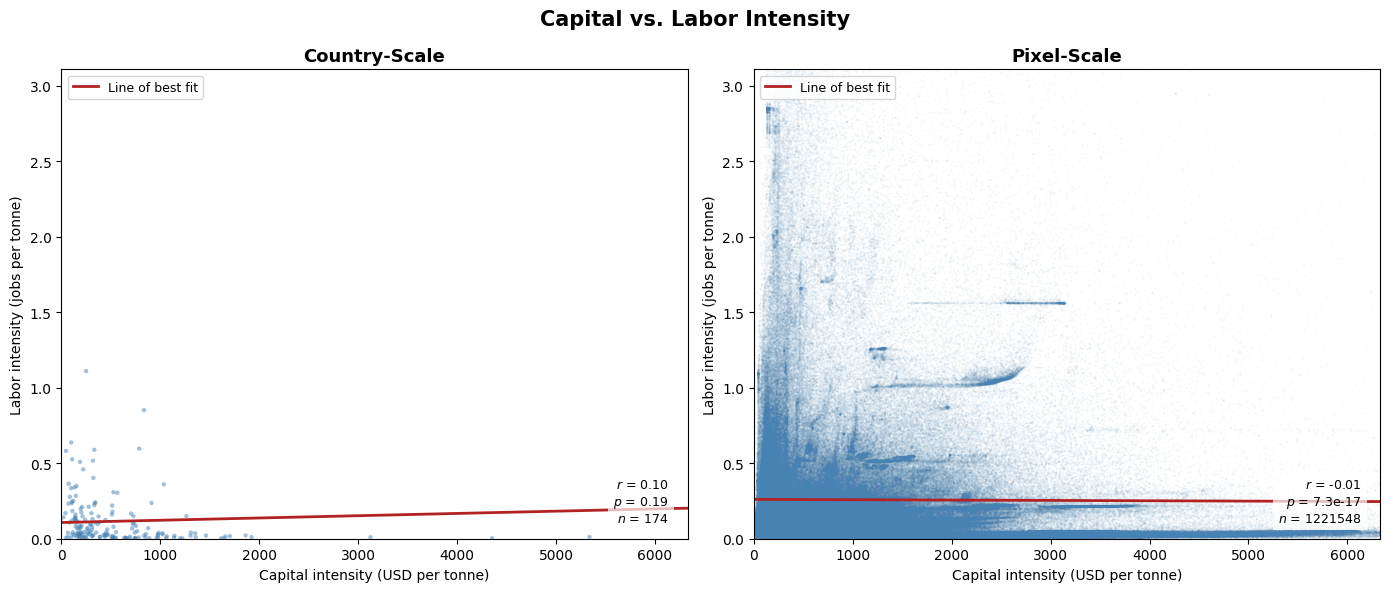

In [12]:
##### Side-by-side scatterplots with line of best fit

def plot_scatter(ax, x, y, lr, title, xlabel, ylabel, xlim, ylim, point_alpha=0.5, point_size=10):
    ax.scatter(x, y, alpha=point_alpha, s=point_size, color="steelblue", edgecolor="none")

    x_line = np.linspace(xlim[0], xlim[1], 100)
    y_line = lr.intercept + lr.slope * x_line
    ax.plot(x_line, y_line, color="firebrick", linewidth=2, label="Line of best fit")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9, loc="upper left")

    ax.text(
        0.97, 0.03,
        f"$r$ = {lr.rvalue:.2f}\n$p$ = {lr.pvalue:.2g}\n$n$ = {len(x)}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )


# shared axis limits: capped at the larger of the two datasets' 99th percentiles
x_cap = max(np.percentile(x_country, 99), np.percentile(x_pixel, 99))
y_cap = max(np.percentile(y_country, 99), np.percentile(y_pixel, 99))

xlim = (0, x_cap)
ylim = (0, y_cap)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_scatter(
    axes[0], x_country, y_country, lr_country,
    title="Country-Scale", xlabel="Capital intensity (USD per tonne)",
    ylabel="Labor intensity (jobs per tonne)",
    xlim=xlim, ylim=ylim
)

plot_scatter(
    axes[1], x_pixel, y_pixel, lr_pixel,
    title="Pixel-Scale", xlabel="Capital intensity (USD per tonne)",
    ylabel="Labor intensity (jobs per tonne)",
    xlim=xlim, ylim=ylim,
    point_alpha=0.05, point_size=2
)

fig.suptitle("Capital vs. Labor Intensity", fontsize=15, weight="bold")
plt.tight_layout()
fig.savefig(f"{fd}/capital_labor_scatter_side_by_side.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
##### Bivariate LMH classification (pixel scale)

def classify_lmh(raster, thresholds=(1/3, 2/3)):
    """
    Classify a raster's valid (finite) values into Low/Medium/High (0/1/2)
    based on distribution terciles of the valid data. Returns a raster
    of the same shape with class codes, NaN preserved where input is NaN.
    """
    vals = raster.squeeze().values
    valid = np.isfinite(vals)

    low_cut, high_cut = np.nanquantile(vals[valid], thresholds)

    classed = np.full(vals.shape, np.nan)
    classed[valid & (vals <= low_cut)] = 0                      # Low
    classed[valid & (vals > low_cut) & (vals <= high_cut)] = 1  # Medium
    classed[valid & (vals > high_cut)] = 2                       # High

    return classed, (low_cut, high_cut)


capital_class, capital_cuts = classify_lmh(capital_intensity)
labor_class, labor_cuts = classify_lmh(labor_intensity)

print(f"\nCapital tercile cutoffs: {capital_cuts}")
print(f"Labor tercile cutoffs: {labor_cuts}")

# combine into single 0-8 class code: class_id = capital_class * 3 + labor_class
combined_valid = np.isfinite(capital_class) & np.isfinite(labor_class)
class_id = np.full(capital_class.shape, np.nan)
class_id[combined_valid] = capital_class[combined_valid] * 3 + labor_class[combined_valid]

# build classified raster, matching capital_intensity's grid/coords
classified_raster = capital_intensity.squeeze().copy(data=class_id)
classified_raster = classified_raster.rio.write_nodata(np.nan)
classified_raster = classified_raster.rio.write_crs(crs)

classified_raster.rio.to_raster(
    f"{cd}/Results/Raster_model/capital_labor_LMH_classification.tif",
    dtype="float32",
    compress="LZW"
)


Capital tercile cutoffs: (np.float64(386.4425964355469), np.float64(1172.8056640625))
Labor tercile cutoffs: (np.float64(25.814491271972656), np.float64(158.5732879638672))


In [ ]:
##### Plot classified raster with country choropleth and 3x3 grid legend

def classify_lmh_from_values(values, thresholds=(1/3, 2/3)):
    """
    Classify an array of values into Low/Medium/High (0/1/2) based on
    tercile cutoffs computed from that array's own distribution.
    Returns the class array and the (low_cut, high_cut) thresholds used.
    """
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    low_cut, high_cut = np.nanquantile(values[valid], thresholds)

    classed = np.full(values.shape, np.nan)
    classed[valid & (values <= low_cut)] = 0
    classed[valid & (values > low_cut) & (values <= high_cut)] = 1
    classed[valid & (values > high_cut)] = 2

    return classed, (low_cut, high_cut)


# classify countries using their OWN distribution's terciles (separate from pixel cutoffs)
country_boundaries['capital_class'], country_capital_cuts = classify_lmh_from_values(
    country_boundaries['capital_intensity_USD_per_tonne']
)
country_boundaries['labor_class'], country_labor_cuts = classify_lmh_from_values(
    country_boundaries['labor_intensity_jobs_per_tonne']
)

print(f"Country capital tercile cutoffs: {country_capital_cuts}")
print(f"Country labor tercile cutoffs: {country_labor_cuts}")

country_combined_valid = country_boundaries['capital_class'].notna() & country_boundaries['labor_class'].notna()
country_boundaries['class_id'] = np.nan
country_boundaries.loc[country_combined_valid, 'class_id'] = (
    country_boundaries.loc[country_combined_valid, 'capital_class'] * 3
    + country_boundaries.loc[country_combined_valid, 'labor_class']
)

# bivariate color scheme: rows = labor class (0=L,1=M,2=H), cols = capital class (0=L,1=M,2=H)
# shared across both panels — same colors mean same L/M/H class in each panel's own distribution
bivariate_colors = {
    (0, 0): '#e8e8e8', (1, 0): '#ace4e4', (2, 0): '#5ac8c8',   # capital = Low
    (0, 1): '#dfb0d6', (1, 1): '#a5add3', (2, 1): '#5698b9',   # capital = Medium
    (0, 2): '#be64ac', (1, 2): '#8c62aa', (2, 2): '#3b4994',   # capital = High
}
# key = (labor_class, capital_class)

cmap_list = [bivariate_colors[(lab, cap)] for cap in range(3) for lab in range(3)]
# ordered to match class_id = capital_class * 3 + labor_class
bivariate_cmap = plt.matplotlib.colors.ListedColormap(cmap_list)
bounds = np.arange(-0.5, 9.5, 1)
norm = plt.matplotlib.colors.BoundaryNorm(bounds, bivariate_cmap.N)

missing_color = "lightgrey"

fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[5, 5, 1], wspace=0.05)

minx, miny, maxx, maxy = country_boundaries.total_bounds

# --- Left panel: country choropleth (own-distribution terciles) ---
ax_country = fig.add_subplot(gs[0])

country_has_data = country_boundaries[country_boundaries['class_id'].notna()]
country_no_data = country_boundaries[country_boundaries['class_id'].isna()]

country_no_data.plot(ax=ax_country, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)
country_has_data.plot(
    ax=ax_country, column="class_id", cmap=bivariate_cmap, norm=norm,
    edgecolor="black", linewidth=0.6, zorder=2
)

ax_country.set_xlim(minx, maxx)
ax_country.set_ylim(miny, maxy)
ax_country.set_axis_off()
ax_country.set_title("Country-Scale Classification", fontsize=14, weight="bold")

# --- Middle panel: pixel raster classification (own-distribution terciles) ---
ax_map = fig.add_subplot(gs[1])

country_boundaries.plot(ax=ax_map, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)

classified_raster.plot(
    ax=ax_map, cmap=bivariate_cmap, norm=norm,
    add_colorbar=False, add_labels=False, zorder=2
)

country_boundaries.plot(ax=ax_map, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

ax_map.set_xlim(minx, maxx)
ax_map.set_ylim(miny, maxy)
ax_map.set_axis_off()
ax_map.set_title("Pixel-Scale Classification", fontsize=14, weight="bold")

fig.suptitle("Capital-Labor Intensity Classification", fontsize=16, weight="bold", y=1.0)

# --- 3x3 grid legend panel (shared) ---
ax_legend = fig.add_subplot(gs[2])
ax_legend.set_aspect("equal")

labels_lmh = ["Low", "Med", "High"]

for cap in range(3):       # x-axis: capital class
    for lab in range(3):   # y-axis: labor class
        ax_legend.add_patch(
            mpatches.Rectangle((cap, lab), 1, 1, facecolor=bivariate_colors[(lab, cap)], edgecolor="white")
        )

ax_legend.set_xlim(0, 3)
ax_legend.set_ylim(0, 3)
ax_legend.set_xticks([0.5, 1.5, 2.5])
ax_legend.set_xticklabels(labels_lmh, fontsize=9)
ax_legend.set_yticks([0.5, 1.5, 2.5])
ax_legend.set_yticklabels(labels_lmh, fontsize=9)
ax_legend.set_xlabel("Capital intensity", fontsize=10)
ax_legend.set_ylabel("Labor intensity", fontsize=10)
ax_legend.set_title("Legend", fontsize=11, weight="bold")
for spine in ax_legend.spines.values():
    spine.set_visible(False)

missing_patch = mpatches.Patch(facecolor=missing_color, edgecolor="black", label="No data")
fig.legend(handles=[missing_patch], loc="lower center", bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=9)

fig.subplots_adjust(top=0.90, bottom=0.1, wspace=0.05)
fig.savefig(f"{fd}/capital_labor_LMH_classification_map.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.show()

Country capital tercile cutoffs: (np.float64(231.93868314176632), np.float64(606.1837118835689))
Country labor tercile cutoffs: (np.float64(0.022697080353739733), np.float64(0.10944783950558601))
